<a href="https://colab.research.google.com/github/rakeshbanisetti/mds_lab/blob/main/numpy4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# Define two arrays
a = np.array([1, 2, 3])
b = np.array([[10], [20], [30]])

# Perform an element-wise operation using broadcasting
c = a + b

# Display the original arrays and the result
print("Array a:")
print(a)
print(a.ndim)
print("\nArray b:")
print(b)
print(b.ndim)
print("\nResult of a + b (broadcasting):")
print(c)

Array a:
[1 2 3]
1

Array b:
[[10]
 [20]
 [30]]
2

Result of a + b (broadcasting):
[[11 12 13]
 [21 22 23]
 [31 32 33]]


In [ ]:
nt

In [ ]:
import numpy as np
a = np.array([1, 2, 3, 4]).reshape(2, 2)
b = np.array([[1, 2], [3, 4]])
res = a + b
print("Array a (reshaped):")
print(a)
print("\nArray b:")
print(b)
print("\nResult of a + b:")
print(res)

Array a (reshaped):
[[1 2]
 [3 4]]

Array b:
[[1 2]
 [3 4]]

Result of a + b:
[[2 4]
 [6 8]]


To run the image processing code, please upload the `lion.jpg` file to your Colab environment or provide a valid path to an image file by modifying the `IMAGE_PATH` variable in the next cell.

In [5]:
import numpy as np
from PIL import Image

# ---- 1. Load image as a NumPy array ----
IMAGE_PATH = "/content/lion.jpg"   # change to your image path
img = Image.open(IMAGE_PATH)
arr = np.array(img)  # shape (H, W, 3) for RGB

print("Image shape (H, W, C):", arr.shape)

# ---- 2. Define eye bounding boxes ----
# Format: (row_start, row_end, col_start, col_end)
# Tune these to match the eyes in your image.
left_box  = (228, 302, 135, 285)
right_box = (228, 302, 395, 565)


def crop(a, box):
    """Crop a region from an array using (y1, y2, x1, x2)."""
    y1, y2, x1, x2 = box
    return a[y1:y2, x1:x2]


left_eye = crop(arr, left_box)
right_eye = crop(arr, right_box)

# ---- 3. Flip operations (pure NumPy) ----
left_eye_flip_h = np.fliplr(left_eye)   # flip left-right (mirror)
left_eye_flip_v = np.flipud(left_eye)   # flip top-bottom
right_eye_flip_h = np.fliplr(right_eye)
right_eye_flip_v = np.flipud(right_eye)

# ---- 4. Draw bounding boxes directly on the array (no drawing library) ----
annotated = arr.copy()


def draw_box(a, box, color=(255, 0, 0), thickness=4):
    """Draw a rectangle outline on array `a` using (y1, y2, x1, x2)."""
    y1, y2, x1, x2 = box
    a[y1:y1 + thickness, x1:x2] = color        # top edge
    a[y2 - thickness:y2, x1:x2] = color        # bottom edge
    a[y1:y2, x1:x1 + thickness] = color        # left edge
    a[y1:y2, x2 - thickness:x2] = color        # right edge


draw_box(annotated, left_box, color=(255, 0, 0))    # red box = left eye
draw_box(annotated, right_box, color=(0, 255, 0))   # green box = right eye

# ---- 5. Save results ----
Image.fromarray(annotated).save("lion_annotated.png")
Image.fromarray(left_eye).save("left_eye.png")
Image.fromarray(right_eye).save("right_eye.png")
Image.fromarray(left_eye_flip_h).save("left_eye_flipped_h.png")
Image.fromarray(right_eye_flip_h).save("right_eye_flipped_h.png")
Image.fromarray(left_eye_flip_v).save("left_eye_flipped_v.png")
Image.fromarray(right_eye_flip_v).save("right_eye_flipped_v.png")

print("Done. Cropped + flipped eye images saved to the current directory.")

Image shape (H, W, C): (998, 700, 3)
Done. Cropped + flipped eye images saved to the current directory.


Left Eye Cropped:


array([[[ 74,  50,  14],
        [ 75,  53,  16],
        [ 72,  50,  13],
        ...,
        [ 88,  56,   7],
        [106,  74,  25],
        [ 97,  63,  15]],

       [[ 54,  30,   0],
        [ 74,  52,  15],
        [ 91,  69,  32],
        ...,
        [ 98,  65,  20],
        [112,  80,  33],
        [102,  68,  22]],

       [[ 60,  38,   0],
        [ 68,  46,   7],
        [ 89,  67,  28],
        ...,
        [100,  67,  24],
        [100,  67,  22],
        [ 96,  63,  18]],

       ...,

       [[130,  98,  51],
        [123,  90,  45],
        [136, 103,  58],
        ...,
        [ 50,  35,  14],
        [ 55,  38,  18],
        [ 48,  31,  11]],

       [[116,  84,  37],
        [137, 105,  58],
        [151, 119,  72],
        ...,
        [ 60,  44,  19],
        [ 55,  37,  13],
        [ 52,  35,   9]],

       [[153, 121,  74],
        [156, 124,  77],
        [152, 120,  73],
        ...,
        [ 63,  46,  20],
        [ 49,  29,   2],
        [ 51,  31,   4]]], dtype=uint8)
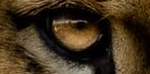

Right Eye Cropped:


array([[[147, 110,  57],
        [146, 109,  56],
        [138, 101,  48],
        ...,
        [244, 170,  75],
        [255, 183,  89],
        [255, 188,  96]],

       [[124,  87,  34],
        [135,  98,  45],
        [132,  95,  42],
        ...,
        [255, 179,  85],
        [255, 190,  95],
        [255, 190,  96]],

       [[120,  83,  31],
        [124,  87,  34],
        [115,  78,  25],
        ...,
        [255, 185,  89],
        [255, 191,  96],
        [255, 184,  89]],

       ...,

       [[220, 150,  64],
        [245, 175,  89],
        [255, 190, 101],
        ...,
        [255, 193, 106],
        [255, 189, 102],
        [255, 185,  99]],

       [[193, 121,  36],
        [229, 158,  70],
        [253, 182,  92],
        ...,
        [250, 188, 103],
        [252, 188, 101],
        [255, 192, 106]],

       [[207, 133,  46],
        [234, 158,  70],
        [249, 176,  84],
        ...,
        [243, 181,  96],
        [245, 183,  98],
        [255, 190, 106]]], dtype=uint8)
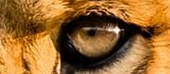

In [11]:
print('Left Eye Cropped:')
display(left_eye)

print('Right Eye Cropped:')
display(right_eye)

### 1. Original Image

This is the image we start with, loaded from `/content/lion.jpg`.

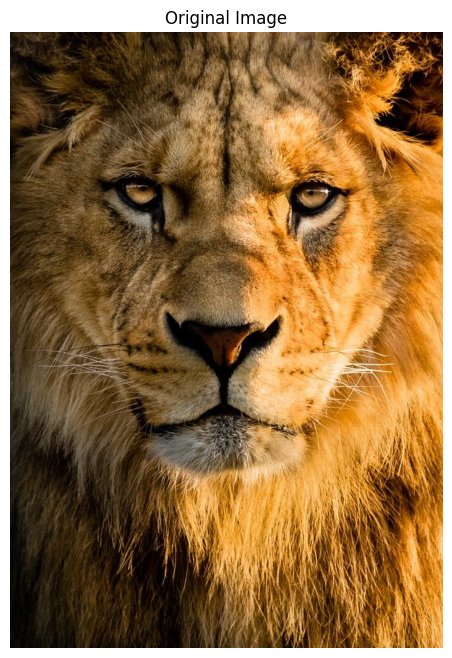

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load the original image again, or use the 'arr' variable if it's still in memory
# For robustness, let's ensure we can load it if 'arr' is not available
if 'arr' not in locals():
    img = Image.open(IMAGE_PATH)
    arr = np.array(img)

plt.figure(figsize=(10, 8))
plt.imshow(arr)
plt.title('Original Image')
plt.axis('off')
plt.show()


### 2. Image as a Numerical Matrix

An image is represented as a NumPy array where each pixel has numerical values for its color channels (e.g., Red, Green, Blue). For a color image, this is a 3D array (Height, Width, Channels). Below is a small snippet of the numerical matrix for the top-left corner of the image, showing the RGB values for each pixel.

In [9]:
print(f"Image shape: {arr.shape} (Height, Width, Channels)")
print("Top-left 5x5 pixel block of the image's numerical matrix (showing RGB values):")
# Display a small section of the array to illustrate the numerical matrix
print(arr[0:5, 0:5, :])

Image shape: (998, 700, 3) (Height, Width, Channels)
Top-left 5x5 pixel block of the image's numerical matrix (showing RGB values):
[[[25 21 10]
  [24 20  8]
  [28 20  9]
  [28 21  5]
  [29 17  1]]

 [[26 22 11]
  [27 23 11]
  [32 24 13]
  [34 27 11]
  [36 24  8]]

 [[25 21 10]
  [27 23 11]
  [34 26 15]
  [39 32 16]
  [43 31 15]]

 [[21 17  6]
  [25 18  8]
  [32 24 13]
  [39 31 18]
  [45 33 19]]

 [[22 15  5]
  [22 15  5]
  [28 20  9]
  [36 28 15]
  [44 32 18]]]


### 3. Identifying the Eyes in the Image

We identify the eyes by defining specific bounding box coordinates (`left_box` and `right_box`) within this numerical matrix. These coordinates tell us the `(row_start, row_end, col_start, col_end)` for each eye. The code then uses NumPy slicing to 'crop' these regions and also draws red and green rectangles on a copy of the original image to visually highlight these identified areas.

Here, the red box indicates the left eye, and the green box indicates the right eye.

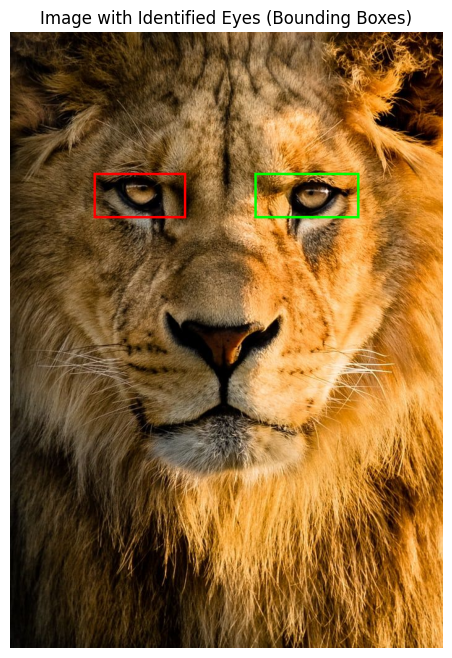

In [10]:
# Use the 'annotated' image array from the previous execution
# If 'annotated' is not in locals (e.g., kernel reset), re-run the original image processing cell first
if 'annotated' not in locals():
    print("\"annotated\" image not found. Please run the image processing cell (X_poaxOdSvbw) first to generate it.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated)
    plt.title('Image with Identified Eyes (Bounding Boxes)')
    plt.axis('off')
    plt.show()

In [ ]:
import os

file_name = 'lion.jpg'
if os.path.exists(file_name):
    print(f"The file '{file_name}' exists in the current directory.")
else:
    print(f"The file '{file_name}' does NOT exist in the current directory.")

The file 'lion.jpg' does NOT exist in the current directory.


The previous code cell attempts to save several image files to the current directory. These files might be consuming disk space. To free up space and return your disk to its state before today's operations, we can delete these generated image files.

In [ ]:
import os

# List of files generated by the image processing cell
generated_files = [
    "lion_annotated.png",
    "left_eye.png",
    "right_eye.png",
    "left_eye_flipped_h.png",
    "right_eye_flipped_h.png",
    "left_eye_flipped_v.png",
    "right_eye_flipped_v.png"
]

# Remove each generated file if it exists
for f_name in generated_files:
    if os.path.exists(f_name):
        os.remove(f_name)
        print(f"Removed '{f_name}'")
    else:
        print(f"'{f_name}' not found, skipping removal.")

print("Disk cleanup complete for generated image files.")

'lion_annotated.png' not found, skipping removal.
'left_eye.png' not found, skipping removal.
'right_eye.png' not found, skipping removal.
'left_eye_flipped_h.png' not found, skipping removal.
'right_eye_flipped_h.png' not found, skipping removal.
'left_eye_flipped_v.png' not found, skipping removal.
'right_eye_flipped_v.png' not found, skipping removal.
Disk cleanup complete for generated image files.


Here's a list of common image files found in the current directory. Please review them and let me know which ones you'd like to delete, or if you'd like to delete all of them.

In [7]:
import os

image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')
image_files = []

for file in os.listdir('.'):
    if file.lower().endswith(image_extensions):
        image_files.append(file)

if image_files:
    print("Found the following image files:")
    for img_file in image_files:
        print(f"- {img_file}")
else:
    print("No common image files found in the current directory.")

Found the following image files:
- left_eye.png
- left_eye_flipped_h.png
- right_eye_flipped_v.png
- lion.jpg
- right_eye.png
- right_eye_flipped_h.png
- lion_annotated.png
- left_eye_flipped_v.png


Let's check the current disk usage to identify what's consuming space.

In [6]:
import shutil

total, used, free = shutil.disk_usage(".")

print(f"Total: {total / (10**9):.2f} GB")
print(f"Used: {used / (10**9):.2f} GB")
print(f"Free: {free / (10**9):.2f} GB")

Total: 120.94 GB
Used: 50.16 GB
Free: 70.77 GB
